<h1>Workshop on Polygenic Scoring</h1>
<h3><b>Volos Summer School 2026</b></br></h3>
<i><h5>Ana Luiza Arruda<br>Konstantinos Hatzikotoulas</h5></i></br>



In this exercise, we will construct a polygenic score for Alzheimer's disease (AD) and apply it to our cohort with individual-level genotype data from the previous workshops.

**Step-by-step**
- Build a Polygenic Score (PGS) by applying LD clumping to a published and publicly available AD GWAS summary statistics
- Harmonise AD GWAS summary statistics with our target individual-level genotype data
- Apply the PGS to two populations of our data using PLINK
- Evaluate performance for a binary (AD) and a quantitative (cognitive function) trait
- Compare the transferability of PGS predictive power across populations

**Goal**: Understand why PGS behaves differently depending on trait architecture and ancestry.

During this practical we will use R and PLINK. Answers to questions are provided in the hidden cells. Please try to answer them yourself first.

To run the first cell please change the runtime type to Python 3. Then change it back to R. You can use `gc()` from time to time to free up memory.

## 1. Setup

In [2]:
# ── Step 1a: Mount Google Drive ──────────────────────────────────
# Run this cell with a Python runtime (Runtime > Change runtime type > Python 3)
# then switch back to R for all subsequent cells
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# ── Step 1b: Set working directory (R runtime) ───────────────────
setwd("/content/drive/My Drive/VSS_2026/PGS_workshop")

In [2]:
# ── Step 1c: Install and load packages ───────────────────────────
install.packages(c("data.table", "ggplot2", "dplyr", "pROC"), quiet = TRUE)

library(data.table)
library(ggplot2)
library(dplyr)
library(pROC)


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




In [3]:
# ── Step 1d: Download and install PLINK ──────────────────────────
cat(system("wget -q https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20210606.zip", intern = TRUE), sep = "\n")
cat(system("unzip -o plink_linux_x86_64_20210606.zip", intern = TRUE), sep = "\n")
cat(system("rm -f prettify toy.* LICENSE", intern = TRUE), sep = "\n")
cat(system("./plink --version", intern = TRUE), sep = "\n")


Archive:  plink_linux_x86_64_20210606.zip
  inflating: plink                   
  inflating: LICENSE                 
  inflating: toy.ped                 
  inflating: toy.map                 
  inflating: prettify                

PLINK v1.90b6.24 64-bit (6 Jun 2021)


## 2. Toy example: what is a PGS?

Before working with real data, let's build intuition with a minimal example.

A **Polygenic Score** is calculated as:

$$\text{PGS}_i = \sum_{j=1}^{M} g_{ij} \times \beta_j$$

Where:
- $g_{ij}$ = number of effect alleles for individual $i$ at SNP $j$ (0, 1, or 2)
- $\beta_j$ = effect size of SNP $j$ from a GWAS
- $M$ = number of SNPs included

The key idea is simple: **we weight each person's genotype by how much each variant is associated with the trait, then sum.**

In [4]:
# Toy example: 10 SNPs, 5 individuals
set.seed(42)

n_snps <- 10
n_individuals <- 5

# Simulate GWAS effect sizes (betas)
toy_beta <- rnorm(n_snps, mean = 0, sd = 0.3)

# Simulate genotype matrix: rows = SNPs, cols = individuals
# Each cell = 0, 1, or 2 (copies of the effect allele)
toy_geno <- matrix(sample(0:2, n_snps * n_individuals, replace = TRUE),
                   nrow = n_snps, ncol = n_individuals)

# Compute PGS: for each individual, sum(genotype * beta) across SNPs
toy_pgs <- colSums(toy_geno * toy_beta)

# Display
cat("Effect sizes (beta):\n"); print(round(toy_beta, 3))
cat("\nGenotype matrix (SNPs x individuals):\n"); print(toy_geno)
cat("\nPGS per individual:\n"); print(round(toy_pgs, 3))

Effect sizes (beta):
 [1]  0.411 -0.169  0.109  0.190  0.121 -0.032  0.453 -0.028  0.606 -0.019

Genotype matrix (SNPs x individuals):
      [,1] [,2] [,3] [,4] [,5]
 [1,]    2    2    1    1    1
 [2,]    2    1    0    1    1
 [3,]    0    0    0    1    0
 [4,]    0    1    1    1    0
 [5,]    2    1    1    2    0
 [6,]    0    2    2    1    2
 [7,]    2    2    2    0    0
 [8,]    0    1    0    1    1
 [9,]    0    1    0    2    0
[10,]    1    1    1    1    0

PGS per individual:
[1] 1.614 2.366 1.547 1.915 0.150


### Question
- What does a higher PGS value mean?
- Why do we need thousands of SNPs in a real PGS?

In [7]:
#@title Answer
cat("A higher PRS means the individual carries more effect alleles, weighted by their GWAS effect sizes.\n")
cat("Most common variants have tiny effects. Summing thousands of SNPs improves predictive power because the signal accumulates \n")
cat("while random noise partially cancels out.\n")

A higher PRS means the individual carries more effect alleles, weighted by their GWAS effect sizes.
Most common variants have tiny effects. Summing thousands of SNPs improves predictive power because the signal accumulates 
while random noise partially cancels out.


## 3. Load & inspect GWAS summary statistics

*   List item
*   List item



We use a published AD GWAS from the GWAS Catalogue:
- Trait: [Alzheimer's disease (MONDO_0004975)](https://www.ebi.ac.uk/gwas/efotraits/MONDO_0004975)
- Study: [GCST007511](https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST007001-GCST008000/GCST007511/)

This file contains, for each variant:
- **SNP**: rsID
- **A1**: effect allele
- **A2**: non-effect allele
- **BETA**: log odds ratio
- **P**: p-value

In [4]:
# Load genome-wide significant GWAS summary statistics (P<5e-8)
gwas <- fread("gws_ad_gwas.txt")
head(gwas)

Chromosome,Position,Effect_allele,Non_Effect_allele,Beta,SE,P,CRSID,SNP
<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,207679307,A,G,0.1324,0.0179,1.598e-13,1:207679307_A_G,rs4844600
1,207684192,T,G,0.1473,0.0185,1.769e-15,1:207684192_G_T,rs12037841
1,207685786,T,C,0.1365,0.0179,2.090e-14,1:207685786_C_T,rs4266886
1,207685965,A,C,0.1472,0.0185,1.826e-15,1:207685965_A_C,rs4562624
1,207692049,A,G,0.1465,0.0185,2.169e-15,1:207692049_A_G,rs6656401
1,207698044,T,C,0.1399,0.0178,4.015e-15,1:207698044_C_T,rs6661489


In [10]:
# Basic inspection
cat("Total variants in GWAS:", nrow(gwas), "\n")
cat("Columns:", paste(colnames(gwas), collapse = ", "), "\n")

Total variants in GWAS: 1514 
Columns: Chromosome, Position, Effect_allele, Non_Effect_allele, Beta, SE, P, CRSID, SNP 


### Question
- How many genome-wide significant variants are there (P < 5×10⁻⁸)?
- What does the BETA column represent for a binary trait like AD?

In [15]:
#@title Answer
cat("Genome-wide significant variants:", sum(gwas$P < 5e-8), "\n")
cat("For a binary trait, BETA is the log odds ratio. Exponentiate to get the odds ratio: exp(BETA)\n")

Genome-wide significant variants: 1514 
For a binary trait, BETA is the log odds ratio. Exponentiate to get the odds ratio: exp(BETA)


## 4. LD clumping

Nearby SNPs in the genome are often correlated due to **linkage disequilibrium (LD)** — they tend to be inherited together. Including all correlated SNPs in a PGS would mean **counting the same signal multiple times**.

### What does clumping do?
For each genomic region, clumping:
1. Selects the most significant SNP as the **index SNP**
2. Removes all SNPs within a window that are correlated (r² > threshold) with it

### Parameters we use:
| Parameter | Value | Meaning |
|-----------|-------|---------|
| `--clump-p1` | 1 | Keep all SNPs as potential index SNPs (no p-value filter here) |
| `--clump-r2` | 0.01 | Remove SNPs with r² > 0.01 with the index SNP |
| `--clump-kb` | 1000 | Look within a 1 Mb window |

We use a **European reference panel** to estimate LD (1000 Genomes EUR).

> ⚠️ Clumping is a simplification. More advanced methods (LDpred, PRSice) model LD directly.

In [ ]:
# Try it yourself — run PLINK clumping
# Hint: use system() with intern = TRUE to capture output
# Reference data: eur_ref_prs_workshop
# GWAS file: gws_ad_gwas.txt
# Output prefix: clumped_ad_gwas

In [19]:
#@title Answer
ref.data.path <- "eur_ref_prs_workshop"
system("mkdir output/")
cat(system(paste(
  "./plink",
  paste0("--bfile ", ref.data.path),
  "--clump gws_ad_gwas.txt",
  "--clump-p1 1",
  "--clump-r2 0.01",
  "--clump-kb 1000",
  "--out output/clumped_ad_gwas"
), intern = TRUE), sep = "\n")

PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to PGS_workshop/output/clumped_ad_gwas.log.
Options in effect:
  --bfile PGS_workshop/eur_ref_prs_workshop
  --clump PGS_workshop/gws_ad_gwas.txt
  --clump-kb 1000
  --clump-p1 1
  --clump-r2 0.01
  --out PGS_workshop/output/clumped_ad_gwas

12975 MB RAM detected; reserving 6487 MB for main workspace.
1333 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to PGS_workshop/output/clumped_ad_gwas.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%3

### Question: How many variants remain after clumping?

In [21]:
#@title Answer
clumped.gwas <- fread("output/clumped_ad_gwas.clumped")
cat("Variants before clumping:", nrow(gwas), "\n")
cat("Variants after clumping: ", nrow(clumped.gwas), "\n")

Variants before clumping: 1514 
Variants after clumping:  40 


## 5. Load & inspect target genotype data

The **target data** is the individual-level genotype dataset that we used in our GWAS and meta-analysis workshops. We will apply the AD PGS on each of the genetic populations (IBS, TSI, GBR, CEU) and compare the predictive power of the PGS on each group.

The data is in PLINK binary format (`.bed/.bim/.fam`).

In [22]:
#Load variant information from the genotype data stored in the .fam file
target.bim <- fread("data_GWAS/1kg_phase1_all_EUR_QCed.bim", col.names = c("CHR","SNP","CM","BP","A1","A2"))
head(target.bim)

CHR,SNP,CM,BP,A1,A2
<int>,<chr>,<int>,<int>,<chr>,<chr>
1,rs180734498,0,13302,T,C
1,rs62637813,0,52058,C,G
1,rs150021059,0,52238,T,G
1,rs141149254,0,54490,A,G
1,rs2462492,0,54676,T,C
1,rs189727433,0,57952,A,C


In [47]:
#Load sample information from the genotype data stored in the .fam file
target.fam <- fread("data_GWAS/1kg_phase1_all_EUR_QCed.fam")
head(target.fam )

V1,V2,V3,V4,V5,V6
<int>,<chr>,<int>,<int>,<int>,<int>
0,HG00096,0,0,1,-9
0,HG00097,0,0,2,-9
0,HG00099,0,0,2,-9
0,HG00100,0,0,2,-9
0,HG00101,0,0,1,-9
0,HG00102,0,0,2,-9


## 6. Harmonisation

Before computing a PGS, we must ensure that the **effect allele in the GWAS** matches the **coded allele in the target genotype data**. If they are misaligned, we would multiply genotypes by the wrong sign, producing an inverted PGS.

### What can go wrong?

| Situation | Problem |
|-----------|---------|
| Effect allele in GWAS ≠ A1 in target | Beta has the wrong sign |
| Strand-ambiguous SNPs (A/T or C/G) | Can't tell if strands are flipped |
| SNP not in target data | Must be excluded |

### Steps:
1. Restrict to clumped SNPs
2. Merge GWAS with target BIM
3. Remove strand-ambiguous SNPs
4. Flip BETA where alleles are swapped
5. Exclude SNPs where alleles don't match at all

> **Note**: We only need to do this in R to produce a clean score file. PLINK's `--score` command will handle allele matching during scoring automatically, but the BETA signs must already be correct.

In [40]:
# ── Step 1: Load target BIM and clumped GWAS ─────────────────────
gwas.clumped  <- gwas[SNP %in% clumped.gwas$SNP]
head(gwas.clumped)


# ── Step 2: Merge target BIM with the clumped GWAS ────────
merged <- merge(target.bim, gwas.clumped[, .(SNP, A1=Effect_allele, A2=Non_Effect_allele, BETA=Beta)],
                by = "SNP", suffixes = c(".target", ".gwas"))
cat("SNPs matched between target and GWAS:", nrow(merged), "\n")

# ── Step 3: Remove strand-ambiguous SNPs ──────────────
ambiguous <- (merged$A1.target == "A" & merged$A2.target == "T") |
             (merged$A1.target == "T" & merged$A2.target == "A") |
             (merged$A1.target == "C" & merged$A2.target == "G") |
             (merged$A1.target == "G" & merged$A2.target == "C")
cat("Strand-ambiguous SNPs removed:", sum(ambiguous), "\n")
merged <- merged[!ambiguous]

# ── Step 4: Flip SNPs where target e do not match GWAS A1 ──
flip_idx <- merged$A1.target != merged$A1.gwas
cat("SNPs where target allele coding differs from GWAS:", sum(flip_idx), "\n")

# For these SNPs, swap A1 and A2 in the target to match GWAS coding
merged$A1.target[flip_idx] <- merged$A1.gwas[flip_idx]
merged$A2.target[flip_idx] <- merged$A2.gwas[flip_idx]

# ── Step 5: Drop SNPs where alleles are incompatible ─────────────
compatible <- (merged$A1.target == merged$A1.gwas) |
              (merged$A1.target == merged$A2.gwas)
merged <- merged[compatible]

cat("SNPs retained after harmonisation:", nrow(merged), "\n")

Chromosome,Position,Effect_allele,Non_Effect_allele,Beta,SE,P,CRSID,SNP
<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,207750568,T,C,0.1508,0.0183,1.555e-16,1:207750568_C_T,rs679515
2,127889932,A,G,0.1330,0.0195,8.955e-12,2:127889932_A_G,rs6710467
2,127892810,T,C,0.1693,0.0154,4.022e-28,2:127892810_C_T,rs6733839
6,32560306,T,C,0.0967,0.0166,5.798e-09,6:32560306_C_T,rs34665982
6,41129252,T,C,0.6989,0.1001,2.948e-12,6:41129252_C_T,rs75932628
6,47595155,A,T,0.0876,0.0157,2.232e-08,6:47595155_A_T,rs1385742


SNPs matched between target and GWAS: 19 
Strand-ambiguous SNPs removed: 4 
SNPs where target allele coding differs from GWAS: 5 
SNPs retained after harmonisation: 15 


## 7. Create PGS score file

In practice, PLINK's `--score` handles allele matching automatically. But it does need the harmonised, clumped SNPs as input. PLINK's `--score` command reads a simple three-column file:
1. SNP ID
2. Effect allele
3. Effect size (BETA)

In [86]:
# Create score file from harmonised, clumped SNPs
score <- gwas.clumped[, .(SNP, A1=Effect_allele, BETA=Beta)]
fwrite(score, "PGS.score", sep = "\t", col.names = FALSE)
writeLines(score$SNP, "score.snps")
cat("Score file written with", nrow(score), "SNPs\n")
head(score)

Score file written with 40 SNPs


SNP,A1,BETA
<chr>,<chr>,<dbl>
rs679515,T,0.1508
rs6710467,A,0.1330
rs6733839,T,0.1693
rs34665982,T,0.0967
rs75932628,T,0.6989
rs1385742,A,0.0876


## 9. Compute PGS per population using PLINK

We now apply the score file to both population A and population B. PLINK multiplies each individual's genotype (0, 1, or 2 copies of the effect allele) by the corresponding BETA, then sums across all SNPs.

We also load phenotype files containing the binary phenotype we are interested on (AD status).


$$\text{PGS}_i = \sum_{j} g_{ij} \times \hat{\beta}_j$$

The `sum` modifier means we get the raw sum (not the mean), which is the standard approach.

In [102]:
# Load phenotype file
pheno.file <- fread("data_GWAS/Data_1kG_SimuPheno.txt")
pheno.file[, unique(LargePop)]
head(pheno.file)
pheno.file <- pheno.file[, .(IID, Population=LargePop, AD=Y_Binary)]

[1] "SEUR" "NEUR"

IID,Population,LargePop,Y_Quanti,Y_Binary
<chr>,<chr>,<chr>,<dbl>,<int>
HG01515,IBS,SEUR,2.553374,1
HG01516,IBS,SEUR,2.390351,0
HG01518,IBS,SEUR,2.860919,1
HG01519,IBS,SEUR,2.506560,1
HG01521,IBS,SEUR,2.509291,1
HG01522,IBS,SEUR,2.472364,0


### Question
- How many individuals are in each population?
- How many AD cases are there per population?

In [ ]:
#@title Answer
cat("Number of individuals per population\n")
pheno.file[, table(Population)]
cat("\nNumber of AD cases per population\n")
pheno.file[AD==1, .N, by=Population]

In [105]:
# Select only samples from the SEUR population
pop.fam <- target.fam[V2 %in% pheno.file[Population=="SEUR", IID]]
fwrite(pop.fam, "SEUR.fam", sep = "\t", col.names = FALSE)

# Compute PGS for the SEUR population
cat(paste0("=== Population SEUR ===\n"))
cat(system(paste(
  "./plink",
  "--bed data_GWAS/1kg_phase1_all_EUR_QCed.bed",
  "--fam data_GWAS/1kg_phase1_all_EUR_QCed.fam",
  "--bim data_GWAS/1kg_phase1_all_EUR_QCed.bim",
  "--keep SEUR.fam",
  "--extract score.snps",
  "--score PGS.score 1 2 3 sum",
  "--out PGS_SEUR"
), intern = TRUE), sep = "\n")


=== Population SEUR ===
PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to PGS_SEUR.log.
Options in effect:
  --bed data_GWAS/1kg_phase1_all_EUR_QCed.bed
  --bim data_GWAS/1kg_phase1_all_EUR_QCed.bim
  --extract score.snps
  --fam data_GWAS/1kg_phase1_all_EUR_QCed.fam
  --keep SEUR.fam
  --out PGS_SEUR
  --score PGS.score 1 2 3 sum

12975 MB RAM detected; reserving 6487 MB for main workspace.
6475080 variants loaded from .bim file.
286 people (143 males, 143 females) loaded from .fam.
--extract: 19 variants remaining.
--keep: 112 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 112 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%

In [106]:
# Select only samples from the NEUR population
pop.fam <- target.fam[V2 %in% pheno.file[Population=="NEUR", IID]]
fwrite(pop.fam, "NEUR.fam", sep = "\t", col.names = FALSE)

# Compute PGS for the NEUR population
cat(paste0("=== Population NEUR ===\n"))
cat(system(paste(
  "./plink",
  "--bed data_GWAS/1kg_phase1_all_EUR_QCed.bed",
  "--bim data_GWAS/1kg_phase1_all_EUR_QCed.bim",
  "--fam data_GWAS/1kg_phase1_all_EUR_QCed.fam",
  "--keep NEUR.fam",
  "--extract score.snps",
  "--score PGS.score 1 2 3 sum",
  "--out PGS_NEUR"
), intern = TRUE), sep = "\n")

=== Population NEUR ===
PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to PGS_NEUR.log.
Options in effect:
  --bed data_GWAS/1kg_phase1_all_EUR_QCed.bed
  --bim data_GWAS/1kg_phase1_all_EUR_QCed.bim
  --extract score.snps
  --fam data_GWAS/1kg_phase1_all_EUR_QCed.fam
  --keep NEUR.fam
  --out PGS_NEUR
  --score PGS.score 1 2 3 sum

12975 MB RAM detected; reserving 6487 MB for main workspace.
6475080 variants loaded from .bim file.
286 people (143 males, 143 females) loaded from .fam.
--extract: 19 variants remaining.
--keep: 174 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 174 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%

## 10. Merge PGS with phenotypes

We merge the PLINK-computed PGS with our true phenotype data for are **AD** (1 = case, 0 = control)

In [107]:
# Load PGS output files
pgs_SEUR <- fread("PGS_SEUR.profile")
pgs_NEUR <- fread("PGS_NEUR.profile")
head(pgs_NEUR)

FID,IID,PHENO,CNT,CNT2,SCORESUM
<int>,<chr>,<int>,<int>,<int>,<dbl>
0,HG00096,-9,38,17,-0.5444
0,HG00097,-9,38,11,0.0601
0,HG00099,-9,38,20,-1.2127
0,HG00100,-9,38,11,-1.1380
0,HG00101,-9,38,13,-0.1193
0,HG00102,-9,38,17,-1.3161


In [110]:
# Merge PGS with phenotypes
df_SEUR <- merge(pheno.file[Population=="SEUR"], pgs_SEUR[, .(IID, SCORESUM)], by = "IID")
df_NEUR <- merge(pheno.file[Population=="NEUR"], pgs_NEUR[, .(IID, SCORESUM)], by = "IID")
head(dfA)

IID,Population,AD,SCORESUM
<chr>,<chr>,<int>,<dbl>
HG01515,SEUR,1,-0.5172
HG01516,SEUR,0,-0.9860
HG01518,SEUR,1,-0.9859
HG01519,SEUR,1,-1.0375
HG01521,SEUR,1,-1.3031
HG01522,SEUR,0,-1.2712


## 11. PGS evaluation

For a **binary trait** like AD, we evaluate PGS performance using:
- **Logistic regression**: PGS + covariates predicting AD case/control status
- **AUC** (Area Under the ROC Curve): ranges from 0.5 (random) to 1.0 (perfect)
- **PGS distribution by case/control status**: cases should have higher PGS on average

In [121]:
# ── Remove empty predictions ──────────────────────────────
df_NEUR <- na.omit(df_NEUR[, .(IID, AD, SCORESUM)])
df_SEUR <- na.omit(df_SEUR[, .(IID, AD, SCORESUM)])

# ── Fit logistic regression ──────────────────────────────
model_ad_NEUR <- glm(AD ~ SCORESUM, data = df_NEUR, family = binomial)
model_ad_SEUR <- glm(AD ~ SCORESUM, data = df_SEUR, family = binomial)

cat("=== Pop NEUR logistic regression summary ===\n")
print(summary(model_ad_NEUR)$coefficients)

cat("\n\n=== Pop SEUR logistic regression summary ===\n")
print(summary(model_ad_SEUR)$coefficients)

# ── Predicted probabilities ──────────────────────────────
pred_ad_NEUR <- predict(model_ad_NEUR, type = "response")
pred_ad_SEUR <- predict(model_ad_SEUR, type = "response")

=== Pop NEUR logistic regression summary ===
               Estimate Std. Error   z value  Pr(>|z|)
(Intercept) 0.005322122  0.2150014 0.0247539 0.9802513
SCORESUM    0.038788800  0.2056778 0.1885901 0.8504141


=== Pop SEUR logistic regression summary ===
            Estimate Std. Error  z value     Pr(>|z|)
(Intercept) 2.081072  0.5268685 3.949888 7.818771e-05
SCORESUM    2.407445  0.5504290 4.373762 1.221238e-05


In [122]:
# ── Calculate AUC ────────────────────────────────────────
auc_ad_NEUR <- auc(df_NEUR$AD, pred_ad_NEUR)
auc_ad_SEUR <- auc(df_SEUR$AD, pred_ad_SEUR)

cat("AUC Pop NEUR:", round(auc_ad_NEUR, 3), "\n")
cat("AUC Pop SEUR:", round(auc_ad_SEUR, 3), "\n")

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



AUC Pop NEUR: 0.512 
AUC Pop SEUR: 0.774 


## 13. Cross-population comparison

A key limitation of PGS is that performance often **degrades when applied across ancestries**. This is because:
- LD patterns differ between populations → clumped SNPs may not represent the same signal
- Effect sizes are estimated in one population and may not generalise
- Allele frequencies differ → the same SNP contributes differently to population-level variance

We compare performance for both traits across populations A and B.

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



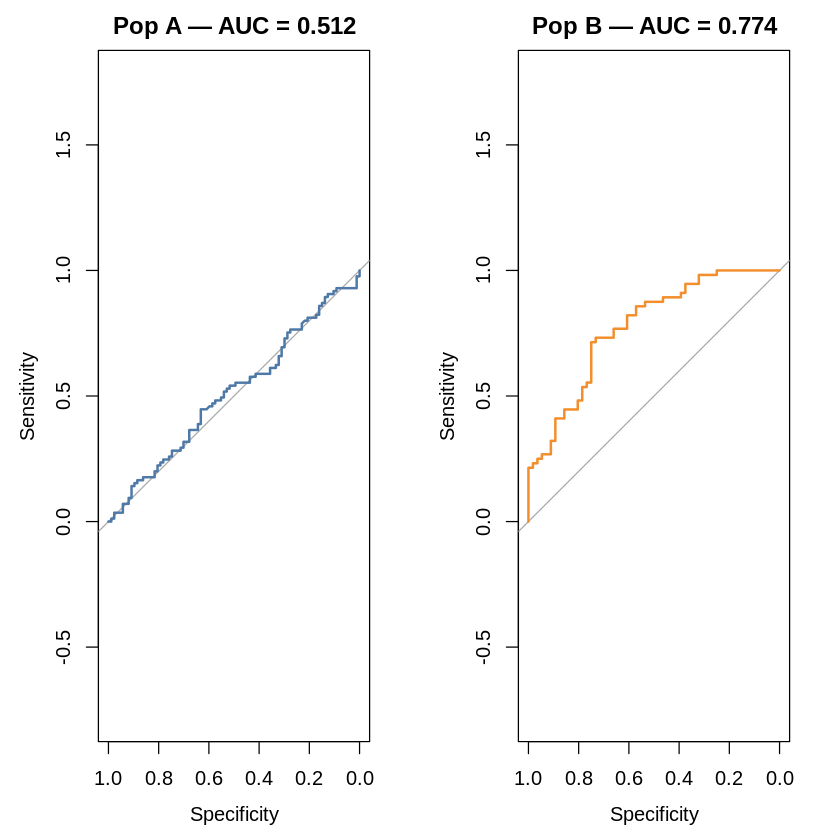

In [124]:
# ── ROC curves ───────────────────────────────────────────
roc_NEUR <- roc(df_NEUR$AD, pred_ad_NEUR)
roc_SEUR <- roc(df_SEUR$AD, pred_ad_SEUR)

par(mfrow = c(1, 2))
plot(roc_NEUR, main = paste0("Pop A — AUC = ", round(auc_ad_NEUR, 3)), col = "#4E79A7", lwd = 2)
plot(roc_SEUR, main = paste0("Pop B — AUC = ", round(auc_ad_SEUR, 3)), col = "#F28E2B", lwd = 2)

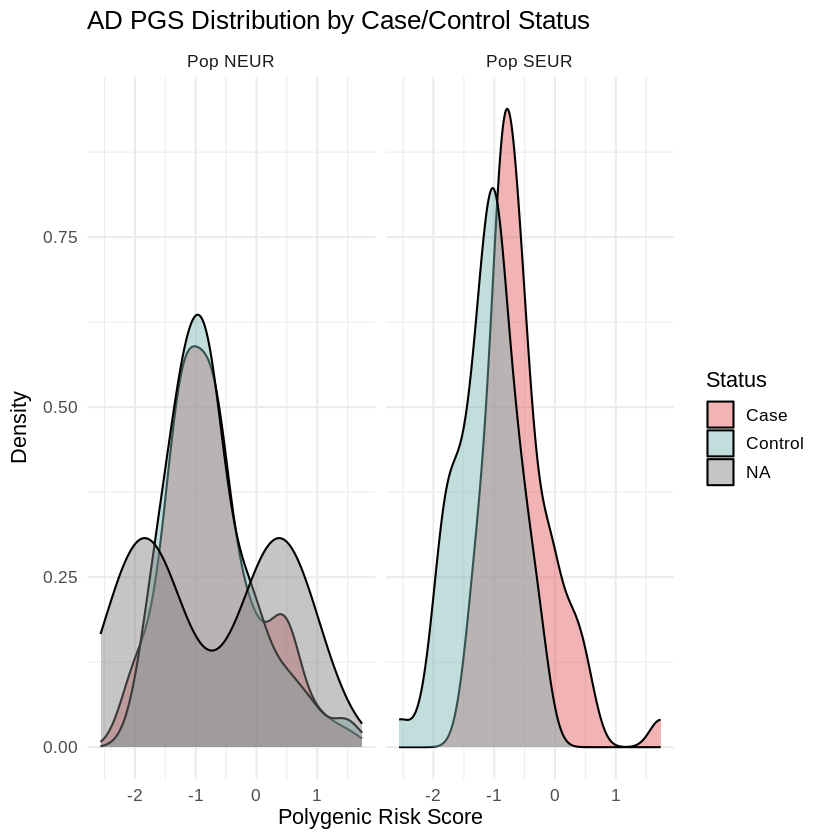

In [119]:
# ── PGS distribution by case/control status ─────────────
df_NEUR$Status <- ifelse(df_NEUR$AD == 1, "Case", "Control")
df_SEUR$Status <- ifelse(df_SEUR$AD == 1, "Case", "Control")
df_NEUR$pop <- "Pop NEUR"
df_SEUR$pop <- "Pop SEUR"

ad_combined <- rbind(df_NEUR, df_SEUR)

ggplot(ad_combined, aes(x = SCORESUM, fill = Status)) +
  geom_density(alpha = 0.45) +
  facet_wrap(~pop) +
  scale_fill_manual(values = c("Case" = "#E15759", "Control" = "#76B7B2")) +
  theme_minimal(base_size = 13) +
  labs(title = "AD PGS Distribution by Case/Control Status",
       x = "Polygenic Risk Score", y = "Density")

### Question
- Is the PGS distribution shifted between cases and controls as expected?
- What does an AUC of 0.774 mean in practice?
- Which population shows better PGS performance, and why might that be?
- What would you do differently if you wanted to improve PGS transferability to Pop NEUR?

In [131]:
#@title Answer
cat("Cases should have a higher mean PRS than controls, reflecting their higher genetic burden.\n")
cat("An AUC of 0.774 means the PRS correctly ranks a randomly chosen case above a randomly chosen\n")
cat("control 77.4% of the time. For a complex trait like AD this is a meaningful result.\n")

cat("\nPop SEUR likely performs better because the GWAS was based predominantly from Southern European samples.\n")
cat("PGS trained in one populations often underperform in other populations due to:\n")
cat("  1. Different LD structure -> clumped SNPs tag different causal variants\n")
cat("  2. Differences in allele frequencies -> effect size estimates are less accurate\n")
cat("  3. Gene-environment interactions that differ by ancestry\n\n")
cat("To improve transferability:\n")
cat("  - Use population-specific GWAS data to derive effect sizes\n")
cat("  - Use population-specific LD reference panels for clumping\n")
cat("  - Apply methods like PRS-CSx that model ancestry jointly\n")

Cases should have a higher mean PRS than controls, reflecting their higher genetic burden.
An AUC of 0.774 means the PRS correctly ranks a randomly chosen case above a randomly chosen
control 77.4% of the time. For a complex trait like AD this is a meaningful result.

Pop SEUR likely performs better because the GWAS was based predominantly from Southern European samples.
PGS trained in one populations often underperform in other populations due to:
  1. Different LD structure -> clumped SNPs tag different causal variants
  2. Differences in allele frequencies -> effect size estimates are less accurate
  3. Gene-environment interactions that differ by ancestry

To improve transferability:
  - Use population-specific GWAS data to derive effect sizes
  - Use population-specific LD reference panels for clumping
  - Apply methods like PRS-CSx that model ancestry jointly


## 14. Key takeaways

### What we did
1. Downloaded and inspected a published AD GWAS
2. Performed LD clumping to obtain independent signals
3. Harmonised GWAS effect alleles with target genotype data
4. Computed PGS for two populations using PLINK
5. Evaluated PGS performance for a binary (AD) trait
6. Compared performance across populations

### Core concepts

| Concept | Key message |
|---------|-------------|
| **PGS** | Weighted sum of effect alleles across the genome |
| **LD clumping** | Removes redundant correlated SNPs to avoid double-counting |
| **Harmonisation** | Ensures GWAS betas have the correct sign relative to target allele coding |
| **AUC** | Performance metric for binary traits; 0.5 = random, 1.0 = perfect |
| **Cross-population** | PGS trained in one ancestry often underperforms in another |

### Limitations of the C+T approach used today
- Clumping + thresholding (C+T) is simple but suboptimal
- More powerful methods: **PRSice-2**, **LDpred2**, **PRS-CSx** (multi-ancestry)
- PGS does not capture gene-environment interactions
- Rare variants are not included (they need burden test approaches)

### Further reading
- [Choi et al. 2020 — PGS tutorial (Nature Protocols)](https://www.nature.com/articles/s41596-020-0353-1)
- [Martin et al. 2019 — Ancestry and PGS portability](https://www.nature.com/articles/s41588-019-0379-x)
- [LDpred2 paper — Privé et al. 2020](https://academic.oup.com/bioinformatics/article/36/22-23/5424/6039173)